In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox



In [2]:
dataframe = pd.read_csv("/Users/v/Data Science Projects/time-series-project/data/retail_sales_mock_data.csv")


check data integrity 

In [3]:
dataframe.info()
#need to convert the columns with dates to datetime 

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Date          48 non-null     str  
 1   SalesAmount   48 non-null     int64
 2   Promotion     48 non-null     int64
 3   HolidayMonth  48 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.6 KB


In [53]:
#dataframe["Order Date"] = pd.to_datetime(dataframe["Order Date"], dayfirst=True)

In [54]:
#postal code needs imputation, but you cannot just impute postal codes plus they are a useless feature so you might just end up dropping those columns 
#dataframe[dataframe["Postal Code"].isna()]


In [4]:
dataframe.head()

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


In [6]:
dataframe.index

RangeIndex(start=0, stop=48, step=1)

In [5]:
dataframe[dataframe.duplicated()]
dataframe.duplicated().sum()
#no duplicates

np.int64(0)

In [7]:

dataframe["Date"] = pd.to_datetime(dataframe["Date"])
dataframe = dataframe.set_index("Date")

In [10]:
dataframe.columns

Index(['SalesAmount', 'Promotion', 'HolidayMonth'], dtype='str')

In [11]:
print(type(dataframe.index))

<class 'pandas.DatetimeIndex'>


In [12]:
#dataframe["#Passengers"].resample(rule="ME").sum().tail

In [13]:
#monthly_sales = dataframe["#Passengers"].resample(rule="ME").sum()
#monthly_sales.head()
#print(type(monthly_sales.index))

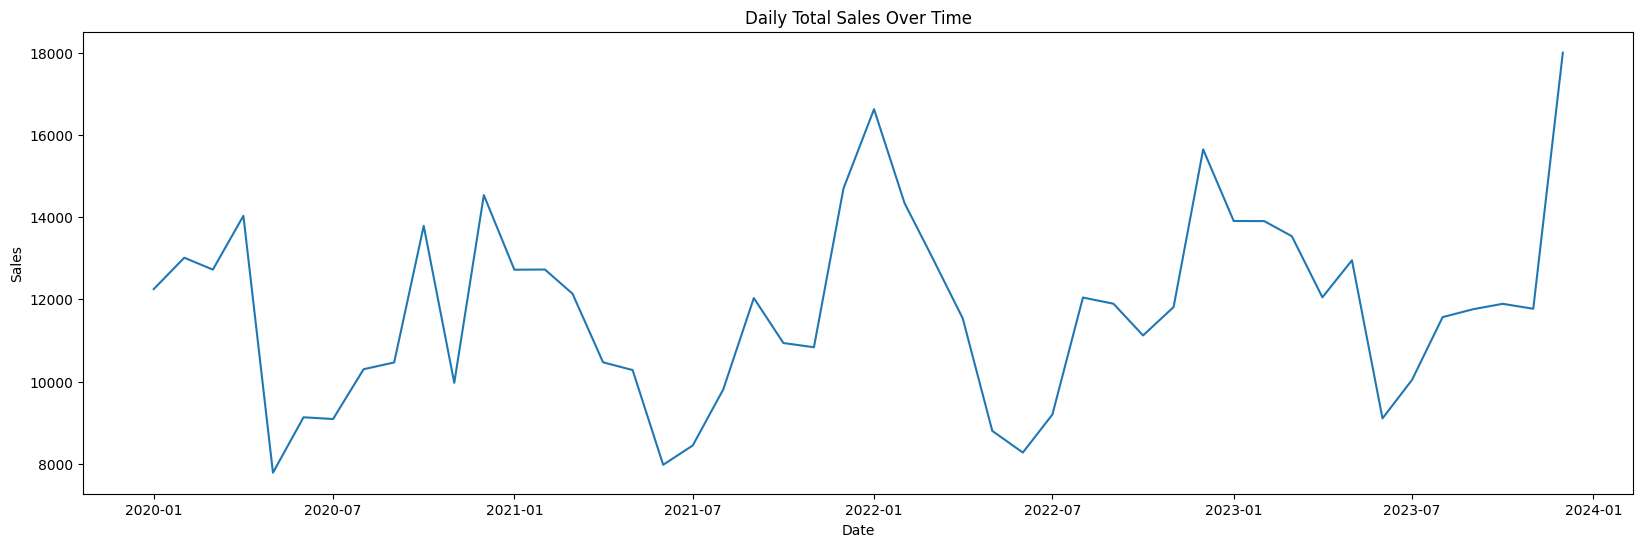

In [14]:
plt.figure(figsize=(20,6))
plt.plot(dataframe.index, dataframe['SalesAmount'])
plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [17]:
def adf_test(series):
    """ADF test for stationarity"""

    test_results = adfuller(series.dropna())

    print('ADF Statistic:', test_results[0])
    print('P-Value:', test_results[1])
    print('Critical Values:')

    for thres, adf_stat in test_results[4].items():
        print(f'\t{thres}: {adf_stat:.2f}')

adf_test(dataframe['SalesAmount'])

ADF Statistic: -4.514183597733958
P-Value: 0.00018535586430261367
Critical Values:
	1%: -3.60
	5%: -2.93
	10%: -2.60


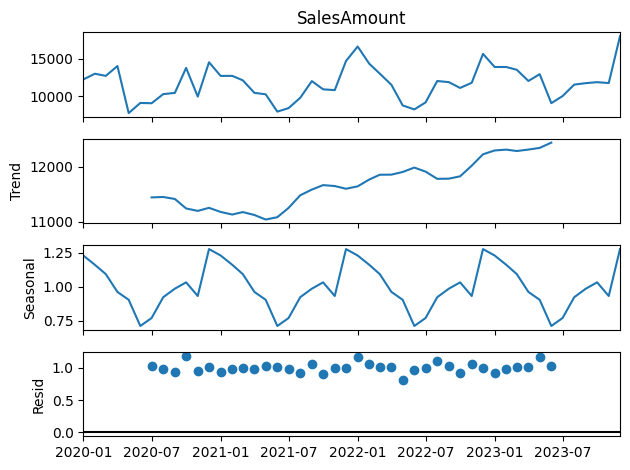

1.0008383731246566


In [21]:
#decompose the series
#i can see that there is clearly seasonaality roughly a trend and seasonality but i should still decompose to inspect it
decomposition_plot_multi = seasonal_decompose(dataframe['SalesAmount'], model= 'multiplicative')
decomposition_plot_multi.plot()
plt. show()
print(np.mean(decomposition_plot_multi.resid))

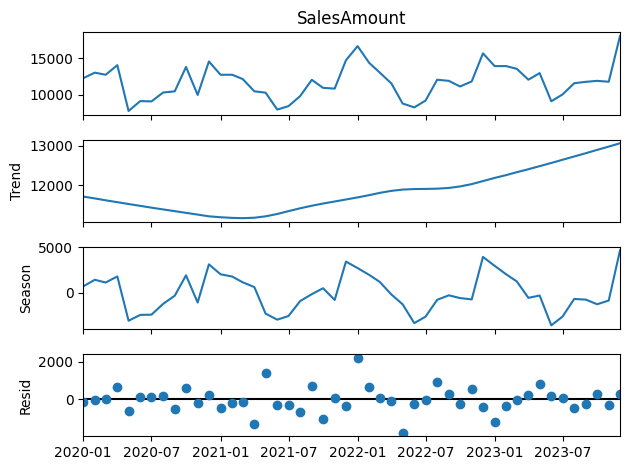

mean:  11768.541666666666
std:  2233.9049979644515
resid mean:  -24.17640292086753


In [24]:
stl = STL(dataframe['SalesAmount'], period=12)
result = stl.fit()
result.plot()
plt.show()
np.mean(result.resid)
print('mean: ',np.mean(dataframe['SalesAmount']))
print('std: ',np.std(dataframe['SalesAmount']))
print('resid mean: ',np.mean(result.resid))

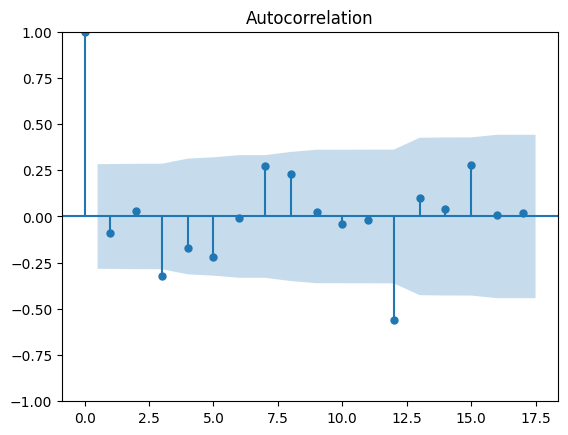

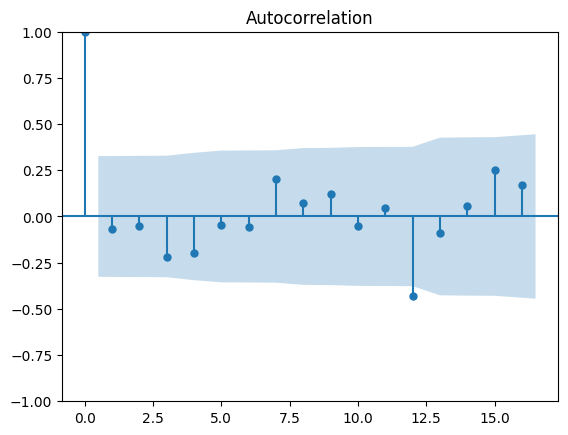

In [27]:
from statsmodels.graphics.tsaplots import plot_acf
plot1 = plot_acf(result.resid.dropna())
plot2 = plot_acf(decomposition_plot_multi.resid.dropna())
plt.show()

<Axes: xlabel='Date'>

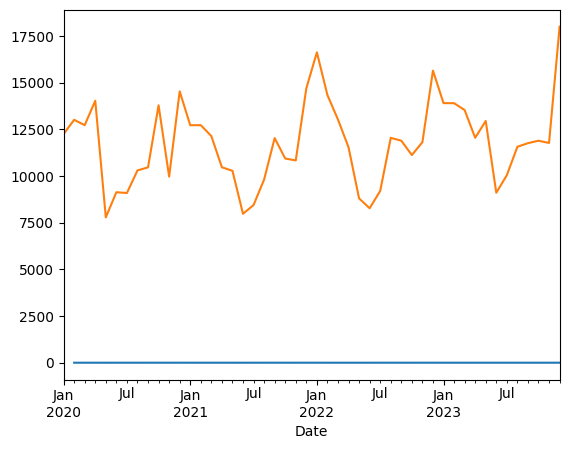

In [29]:
#check stationailty
log_data = np.log(dataframe['SalesAmount'])
log_diff_data = log_data.diff()
log_diff_data.plot()
dataframe['SalesAmount'].plot()

In [ ]:
def adf_test(series):
    """ADF test for stationarity"""

    test_results = adfuller(series.dropna())

    print('ADF Statistic:', test_results[0])
    print('P-Value:', test_results[1])
    print('Critical Values:')

    for thres, adf_stat in test_results[4].items():
        print(f'\t{thres}: {adf_stat:.2f}')

adf_test(monthly_sales)

ADF Statistic: -14.730254534805095
P-Value: 2.6665992769114295e-27
Critical Values:
	1%: -3.49
	5%: -2.89
	10%: -2.58


0.1480226858137178


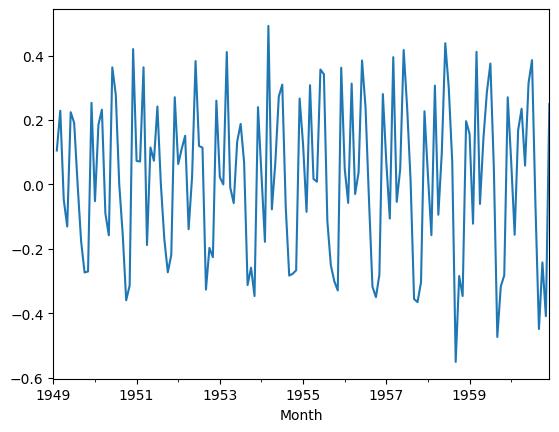

In [28]:
#check stationailty
log_data,lam = boxcox(monthly_sales)
log_data = pd.Series(
    log_data,
    index=monthly_sales.index
)
log_diff_data = log_data.diff()
log_diff_data.plot()
print(lam)

In [29]:
# ADF test


def adf_test(series):
    """ADF test for stationarity"""

    test_results = adfuller(series.dropna())

    print('ADF Statistic:', test_results[0])
    print('P-Value:', test_results[1])
    print('Critical Values:')

    for thres, adf_stat in test_results[4].items():
        print(f'\t{thres}: {adf_stat:.2f}')

adf_test(log_diff_data)


ADF Statistic: -2.8717075604826934
P-Value: 0.048738329956577835
Critical Values:
	1%: -3.48
	5%: -2.88
	10%: -2.58


Box-Cox transform is better and should thus be used

data is now stationary

now begin the Autocorrelation analysis: acf and pacf
this is done just to visualise. in the pipeline i will use cross validation to select p and q